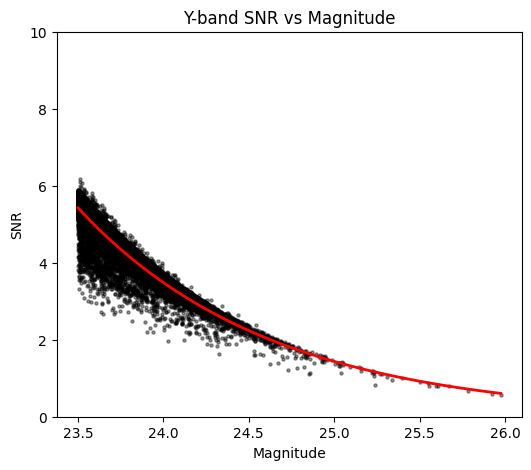

Y-band SNR 1 → mag -25.41
Y-band SNR 2 → mag -24.63
Y-band SNR 3 → mag -24.17
Y-band SNR 4 → mag -23.84
Y-band SNR 5 → mag -23.59


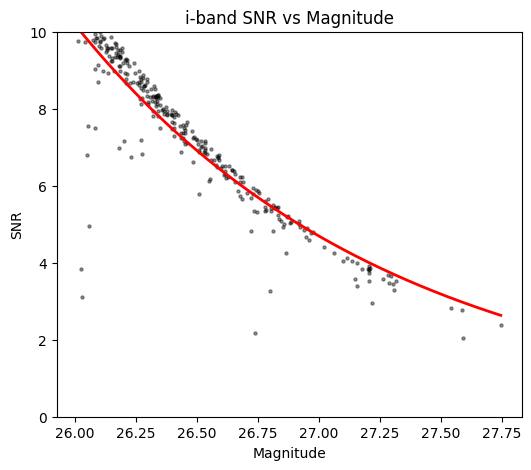

i-band SNR 1 → mag -28.99
i-band SNR 2 → mag -28.10
i-band SNR 3 → mag -27.58
i-band SNR 4 → mag -27.21
i-band SNR 5 → mag -26.92


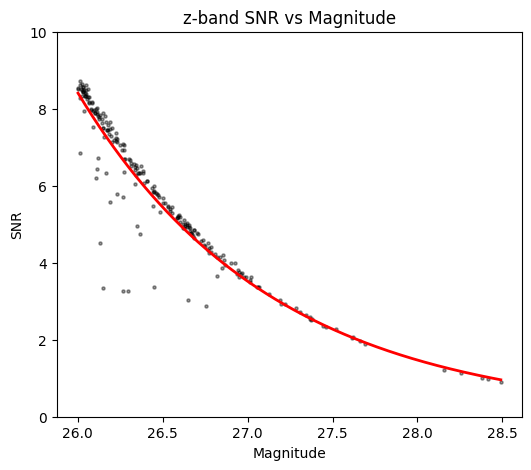

z-band SNR 1 → mag -28.44
z-band SNR 2 → mag -27.65
z-band SNR 3 → mag -27.18
z-band SNR 4 → mag -26.85
z-band SNR 5 → mag -26.60
0.4605170185988092


In [16]:
import numpy as np
import pandas as pd
from astropy.coordinates import SkyCoord
import astropy.units as u
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

from astropy.stats import sigma_clip

# ---------- File paths ----------
i_file  = "/Users/aishwarya/Desktop/new_cdfs/cat/LBG_I_CDFS_depth.cat"
z_file  = "/Users/aishwarya/Desktop/new_cdfs/cat/LBG_Z_CDFS_depth.cat"
y_file  = "/Users/aishwarya/Desktop/new_cdfs/cat/LBG_Y_CDFS_depth.cat"

# ---------- Load catalogs ----------
colnames = ["ID", "X", "Y", "RA", "DEC",
            "MAG_APER", "MAGERR_APER",
            "MAG_AUTO", "MAGERR_AUTO",
            "FLAGS", "ISOAREA_IMAGE"]

i_df = pd.read_csv(i_file, sep=r"\s+", comment="#", names=colnames)
z_df = pd.read_csv(z_file, sep=r"\s+", comment="#", names=colnames)
y_df = pd.read_csv(y_file, sep=r"\s+", comment="#", names=colnames)

# ---------- Zero points ----------
ZP_i, ZP_z, ZP_y = 31.349 , 31.509, 30.0807
zp_err_i, zp_err_z, zp_err_y = 0.003, 0.003, 0.0067

for df, zp, zp_err in zip([i_df, z_df, y_df], [ZP_i, ZP_z, ZP_y], [zp_err_i, zp_err_z, zp_err_y]):
    df["MAG_APER_CAL"] = df["MAG_APER"] + zp
    df["MAGERR_APER_CAL"] = np.sqrt(df["MAGERR_APER"]**2 + zp_err**2)

# ---------- SNR ----------
def calculate_snr(err):
    """Converts magnitude errors to SNR"""
    snr = 2.5 / (np.log(10) * err)
    snr[~np.isfinite(snr)] = np.nan
    return snr

# ---------- Cross-match ----------
nb_coords = SkyCoord(y_df.RA.values*u.deg, y_df.DEC.values*u.deg)
z_coords  = SkyCoord(z_df.RA.values*u.deg, z_df.DEC.values*u.deg)
i_coords  = SkyCoord(i_df.RA.values*u.deg, i_df.DEC.values*u.deg)

idx_z, sep_z, _ = nb_coords.match_to_catalog_sky(z_coords)
idx_i, sep_i, _ = nb_coords.match_to_catalog_sky(i_coords)

match_radius = 1.0  # arcsec
z_match = sep_z.arcsec < match_radius
i_match = sep_i.arcsec < match_radius

def align_mag_err(n, df, idx, mask):
    mag = np.full(n, np.nan)
    err = np.full(n, np.nan)
    mag[mask] = df.MAG_APER_CAL.values[idx[mask]]
    err[mask] = df.MAGERR_APER_CAL.values[idx[mask]]
    return mag, err

y_mag = y_df.MAG_APER_CAL.values
y_err = y_df.MAGERR_APER_CAL.values
z_mag, z_err = align_mag_err(len(y_mag), z_df, idx_z, z_match)
i_mag, i_err = align_mag_err(len(y_mag), i_df, idx_i, i_match)

# ---------- Common mask ----------
mask = (~np.isnan(y_mag)) & (~np.isnan(z_mag)) & (~np.isnan(i_mag))
y_mag, y_err = y_mag[mask], y_err[mask]
z_mag, z_err = z_mag[mask], z_err[mask]
i_mag, i_err = i_mag[mask], i_err[mask]

# ---------- Filter SNR ----------
snr_y = calculate_snr(y_err)
good = (snr_y > 0) & (snr_y < 30) & (y_mag > 21)

y_mag, y_err = y_mag[good], y_err[good]
z_mag, z_err = z_mag[good], z_err[good]
i_mag, i_err = i_mag[good], i_err[good]


# ---------- Exponential fit function ----------
def exponential_func(x, a, b):
    return a * np.exp(-b * x)

def fit_snr_exponential(mag, err, bandname):

    snr = calculate_snr(err)

    valid = np.isfinite(mag) & np.isfinite(snr)
    mag = mag[valid]
    snr = snr[valid]

    snr_mask = (snr > 0.5) & (snr < 10)
    mag = mag[snr_mask]
    snr = snr[snr_mask]

    if bandname == "Y-band":
        mag_mask = (mag > 23.5) & (mag < 26)

    elif bandname == "i-band":
        mag_mask = (mag > 26) & (mag < 28)

    else:
        mag_mask = (mag > 26) & (mag < 28.5)

    mag = mag[mag_mask]
    snr = snr[mag_mask]

    if len(mag) < 20:
        print(f"{bandname}: Not enough points")
        return None

    params, cov = curve_fit(
        exponential_func,
        mag,
        snr,
        p0=[1e6, 0.2],
        maxfev=10000
    )

    a_fit, b_fit = params
    a_err, b_err = np.sqrt(np.diag(cov))

    x_finer = np.linspace(mag.min(), mag.max(), 1000)
    y_fit = exponential_func(x_finer, a_fit, b_fit)

    plt.figure(figsize=(6,5))
    plt.scatter(mag, snr, s=5, color="black", alpha=0.4)
    plt.plot(x_finer, y_fit, color="red", lw=2)
    plt.ylim(0,10)
    plt.xlabel("Magnitude")
    plt.ylabel("SNR")
    plt.title(f"{bandname} SNR vs Magnitude")
    plt.show()

    def magnitude_at_snr(s):
        return np.log(s / a_fit) / b_fit

    for s in [1,2,3,4,5]:
        print(f"{bandname} SNR {s} → mag {magnitude_at_snr(s):.2f}")

    return magnitude_at_snr(5)
# ---------- Run fits ----------
lim_y = fit_snr_exponential(y_mag, y_err, "Y-band")
lim_i = fit_snr_exponential(i_mag, i_err, "i-band")
lim_z = fit_snr_exponential(z_mag, z_err, "z-band")
print(0.2*np.log(10))


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit, brentq
from astropy.coordinates import SkyCoord
import astropy.units as u

# ============================================================
# File paths
# ============================================================
i_file  = "/Users/aishwarya/Desktop/new_cdfs/cat/LBG_I_CDFS_depth.cat"
z_file  = "/Users/aishwarya/Desktop/new_cdfs/cat/LBG_Z_CDFS_depth.cat"
y_file  = "/Users/aishwarya/Desktop/new_cdfs/cat/LBG_Y_CDFS_depth.cat"

# ============================================================
# Load catalogs
# ============================================================
colnames = ["ID", "X", "Y", "RA", "DEC",
            "MAG_APER", "MAGERR_APER",
            "MAG_AUTO", "MAGERR_AUTO", "FLAGS"]

i_df = pd.read_csv(i_file, sep=r"\s+", comment="#", names=colnames)
z_df = pd.read_csv(z_file, sep=r"\s+", comment="#", names=colnames)
y_df = pd.read_csv(y_file, sep=r"\s+", comment="#", names=colnames)

# ============================================================
# Zero points
# ============================================================
ZP_i, ZP_z, ZP_y = 31.349 , 31.509, 30.0807
zp_err_i, zp_err_z, zp_err_y = 0.003, 0.003, 0.0067

for df, zp, zp_err in zip(
        [i_df, z_df, y_df],
        [ZP_i, ZP_z, ZP_y],
        [zp_err_i, zp_err_z, zp_err_y]):

    df["MAG_APER_CAL"] = df["MAG_APER"] + zp
    df["MAGERR_APER_CAL"] = np.sqrt(df["MAGERR_APER"]**2 + zp_err**2)

# ============================================================
# Cross-match to align catalogs
# ============================================================
y_coords = SkyCoord(y_df.RA.values*u.deg, y_df.DEC.values*u.deg)
z_coords = SkyCoord(z_df.RA.values*u.deg, z_df.DEC.values*u.deg)
i_coords = SkyCoord(i_df.RA.values*u.deg, i_df.DEC.values*u.deg)

idx_z, sep_z, _ = y_coords.match_to_catalog_sky(z_coords)
idx_i, sep_i, _ = y_coords.match_to_catalog_sky(i_coords)

match_radius = 1.0  # arcsec
z_match = sep_z.arcsec < match_radius
i_match = sep_i.arcsec < match_radius

def align_mag_err(n, df, idx, mask):
    mag = np.full(n, np.nan)
    err = np.full(n, np.nan)
    mag[mask] = df.MAG_APER_CAL.values[idx[mask]]
    err[mask] = df.MAGERR_APER_CAL.values[idx[mask]]
    return mag, err

y_mag = y_df.MAG_APER_CAL.values
y_err = y_df.MAGERR_APER_CAL.values

z_mag, z_err = align_mag_err(len(y_mag), z_df, idx_z, z_match)
i_mag, i_err = align_mag_err(len(y_mag), i_df, idx_i, i_match)

# ============================================================
# Common mask
# ============================================================
mask = (~np.isnan(y_mag)) & (~np.isnan(z_mag)) & (~np.isnan(i_mag))

y_mag, y_err = y_mag[mask], y_err[mask]
z_mag, z_err = z_mag[mask], z_err[mask]
i_mag, i_err = i_mag[mask], i_err[mask]

# ============================================================
# Stable exponential sigma model
# sigma(m) = a * exp(b*m) + c
# ============================================================

def sigma_model(m, a, b, c):
    # Clip exponent to avoid overflow
    exponent = np.clip(b * m, -100, 100)
    return a * np.exp(exponent) + c

def fit_sigma_exponential(mag, err, bandname):

    # Clean data
    valid = np.isfinite(mag) & np.isfinite(err)
    mag = mag[valid]
    err = err[valid]

    # Restrict to faint regime (background dominated)
    mask_range = (mag > 20) & (mag < 30)
    mag = mag[mask_range]
    err = err[mask_range]

    # Initial guess (physically motivated)
    p0 = [1e-7, 0.45, 0.001]

    # Bounds to prevent nonsense solutions
    bounds = (
        [1e-12, 0.0, 0.0],   # lower bounds
        [1e-2,   2.0,  0.1]  # upper bounds
    )

    popt, pcov = curve_fit(
        sigma_model,
        mag,
        err,
        p0=p0,
        bounds=bounds,
        maxfev=20000
    )

    a_fit, b_fit, c_fit = popt
    print(f"\n{bandname} fit parameters:")
    print("a, b, c =", popt)

    # ========================================================
    # Plot
    # ========================================================
    x_fine = np.linspace(mag.min(), mag.max(), 1000)
    y_fit = sigma_model(x_fine, *popt)

    plt.figure(figsize=(6,5))
    plt.scatter(mag, err, s=5, alpha=0.4, color='black')
    plt.plot(x_fine, y_fit, color='red', lw=2)
    plt.xlabel("Magnitude")
    plt.ylabel("Magnitude Error")
    plt.title(f"{bandname} σ(m) fit")
    #plt.xlim(25,28)
    plt.ylim(0,0.6)
    plt.show()

    # ========================================================
    # Compute 5σ depth
    # ========================================================
    sigma_5 = 2.5 / (np.log(10) * 1)

    def root_func(m):
        return sigma_model(m, *popt) - sigma_5

    m_5sigma = brentq(root_func, 20, 30)

    print(f"{bandname} 5σ depth = {m_5sigma:.2f}")

    return popt, m_5sigma

# ============================================================
# Run fits
# ============================================================

popt_y, lim_y = fit_sigma_exponential(y_mag, y_err, "Y-band")
popt_i, lim_i = fit_sigma_exponential(i_mag, i_err, "i-band")
popt_z, lim_z = fit_sigma_exponential(z_mag, z_err, "z-band")

print("\nFinal 5σ depths:")
print("Y:", lim_y)
print("i:", lim_i)
print("z:", lim_z)

ValueError: Latitude angle(s) must be within -90 deg <= angle <= 90 deg, got -16.0055 deg <= angle <= 99.0 deg

# Give 1 to 5 sigma


Y-band fit parameters:
a, b, c = [4.30478471e-11 9.34660924e-01 6.44706262e-03]


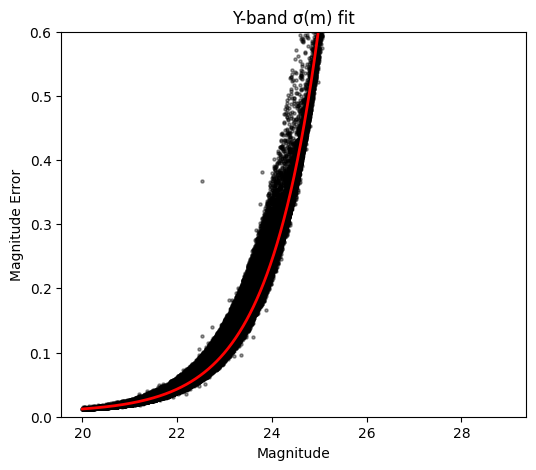


Y-band depths:
1σ depth = 25.62
2σ depth = 24.87
3σ depth = 24.43
4σ depth = 24.12
5σ depth = 23.87

i-band fit parameters:
a, b, c = [1.00000000e-12 9.89098551e-01 4.13200920e-03]


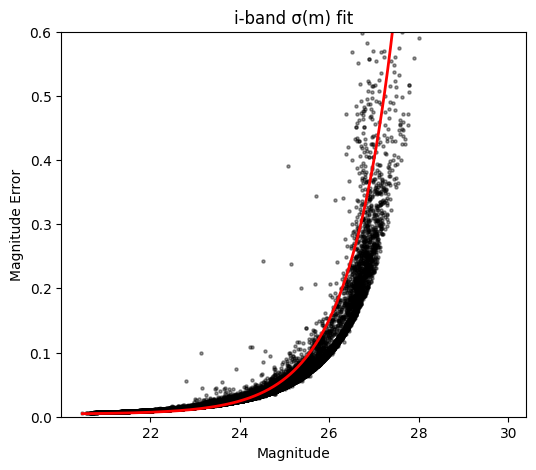


i-band depths:
1σ depth = 28.01
2σ depth = 27.31
3σ depth = 26.90
4σ depth = 26.60
5σ depth = 26.37

z-band fit parameters:
a, b, c = [1.00000001e-12 9.86804180e-01 7.06568501e-03]


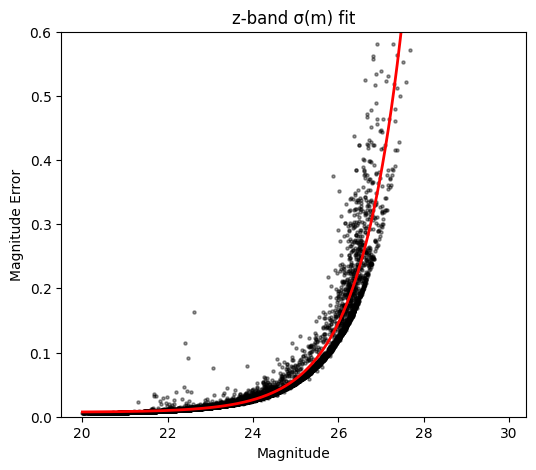


z-band depths:
1σ depth = 28.08
2σ depth = 27.37
3σ depth = 26.95
4σ depth = 26.65
5σ depth = 26.42

Final depth summary (mag):
1σ:  Y=25.62   i=28.01   z=28.08
2σ:  Y=24.87   i=27.31   z=27.37
3σ:  Y=24.43   i=26.90   z=26.95
4σ:  Y=24.12   i=26.60   z=26.65
5σ:  Y=23.87   i=26.37   z=26.42


In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit, brentq
from astropy.coordinates import SkyCoord
import astropy.units as u

# ============================================================
# File paths
# ============================================================
i_file  = "/Users/aishwarya/Desktop/new_cdfs/cat/LBG_I_CDFS_depth.cat"
z_file  = "/Users/aishwarya/Desktop/new_cdfs/cat/LBG_Z_CDFS_depth.cat"
y_file  = "/Users/aishwarya/Desktop/new_cdfs/cat/LBG_Y_CDFS_depth.cat"

# ============================================================
# Load catalogs
# ============================================================
colnames = ["ID", "X", "Y", "RA", "DEC",
            "MAG_APER", "MAGERR_APER",
            "MAG_AUTO", "MAGERR_AUTO", "FLAGS"]

i_df = pd.read_csv(i_file, sep=r"\s+", comment="#", names=colnames)
z_df = pd.read_csv(z_file, sep=r"\s+", comment="#", names=colnames)
y_df = pd.read_csv(y_file, sep=r"\s+", comment="#", names=colnames)

# ============================================================
# Zero points
# ============================================================
ZP_i, ZP_z, ZP_y = 31.354, 31.524, 30.3382
zp_err_i, zp_err_z, zp_err_y = 0.004, 0.004, 0.009

for df, zp, zp_err in zip(
        [i_df, z_df, y_df],
        [ZP_i, ZP_z, ZP_y],
        [zp_err_i, zp_err_z, zp_err_y]):

    df["MAG_APER_CAL"] = df["MAG_APER"] + zp
    df["MAGERR_APER_CAL"] = np.sqrt(df["MAGERR_APER"]**2 + zp_err**2)

# ============================================================
# Cross-match catalogs to Y-band reference
# ============================================================
y_coords = SkyCoord(y_df.RA.values*u.deg, y_df.DEC.values*u.deg)
z_coords = SkyCoord(z_df.RA.values*u.deg, z_df.DEC.values*u.deg)
i_coords = SkyCoord(i_df.RA.values*u.deg, i_df.DEC.values*u.deg)

idx_z, sep_z, _ = y_coords.match_to_catalog_sky(z_coords)
idx_i, sep_i, _ = y_coords.match_to_catalog_sky(i_coords)

match_radius = 1.0  # arcsec
z_match = sep_z.arcsec < match_radius
i_match = sep_i.arcsec < match_radius

def align_mag_err(n, df, idx, mask):
    mag = np.full(n, np.nan)
    err = np.full(n, np.nan)
    mag[mask] = df.MAG_APER_CAL.values[idx[mask]]
    err[mask] = df.MAGERR_APER_CAL.values[idx[mask]]
    return mag, err

y_mag = y_df.MAG_APER_CAL.values
y_err = y_df.MAGERR_APER_CAL.values

z_mag, z_err = align_mag_err(len(y_mag), z_df, idx_z, z_match)
i_mag, i_err = align_mag_err(len(y_mag), i_df, idx_i, i_match)

# ============================================================
# Common mask (sources detected in all bands)
# ============================================================
mask = (~np.isnan(y_mag)) & (~np.isnan(z_mag)) & (~np.isnan(i_mag))

y_mag, y_err = y_mag[mask], y_err[mask]
z_mag, z_err = z_mag[mask], z_err[mask]
i_mag, i_err = i_mag[mask], i_err[mask]

# ============================================================
# Exponential sigma model
# sigma(m) = a * exp(b*m) + c
# ============================================================

def sigma_model(m, a, b, c):
    exponent = np.clip(b * m, -100, 100)  # numerical safety
    return a * np.exp(exponent) + c


# ============================================================
# Compute N-sigma depths
# ============================================================

def compute_sigma_depths(popt, bandname, mag_min=20, mag_max=30):

    sigma_levels = [1, 2, 3, 4, 5]
    depths = {}

    print(f"\n{bandname} depths:")

    for N in sigma_levels:

        # Convert SNR to magnitude error
        sigma_N = 2.5 / (np.log(10) * N)

        def root_func(m):
            return sigma_model(m, *popt) - sigma_N

        try:
            m_N = brentq(root_func, mag_min, mag_max)
            depths[N] = m_N
            print(f"{N}σ depth = {m_N:.2f}")
        except ValueError:
            depths[N] = np.nan
            print(f"{N}σ depth could not be solved")

    return depths


# ============================================================
# Fit function
# ============================================================

def fit_sigma_exponential(mag, err, bandname):

    valid = np.isfinite(mag) & np.isfinite(err)
    mag = mag[valid]
    err = err[valid]

    # Background-dominated regime
    mask_range = (mag > 20) & (mag < 30)
    mag = mag[mask_range]
    err = err[mask_range]

    p0 = [1e-7, 0.45, 0.001]

    bounds = (
        [1e-12, 0.0, 0.0],
        [1e-2,   2.0,  0.1]
    )

    popt, pcov = curve_fit(
        sigma_model,
        mag,
        err,
        p0=p0,
        bounds=bounds,
        maxfev=20000
    )

    print(f"\n{bandname} fit parameters:")
    print("a, b, c =", popt)

    # Plot
    x_fine = np.linspace(mag.min(), mag.max(), 1000)
    y_fit = sigma_model(x_fine, *popt)

    plt.figure(figsize=(6,5))
    plt.scatter(mag, err, s=5, alpha=0.4, color='black')
    plt.plot(x_fine, y_fit, color='red', lw=2)
    plt.xlabel("Magnitude")
    plt.ylabel("Magnitude Error")
    plt.title(f"{bandname} σ(m) fit")
    plt.ylim(0,0.6)
    plt.show()

    # Compute 1–5σ depths
    depths = compute_sigma_depths(popt, bandname)

    return popt, depths


# ============================================================
# Run fits
# ============================================================

popt_y, depths_y = fit_sigma_exponential(y_mag, y_err, "Y-band")
popt_i, depths_i = fit_sigma_exponential(i_mag, i_err, "i-band")
popt_z, depths_z = fit_sigma_exponential(z_mag, z_err, "z-band")

# ============================================================
# Final summary
# ============================================================

print("\nFinal depth summary (mag):")
for N in range(1,6):
    print(f"{N}σ:  Y={depths_y[N]:.2f}   i={depths_i[N]:.2f}   z={depths_z[N]:.2f}")

# Trial 1


Y-band fit parameters:
a, b, c = [1.00000000e-12 9.77539078e-01 2.07208896e-02]


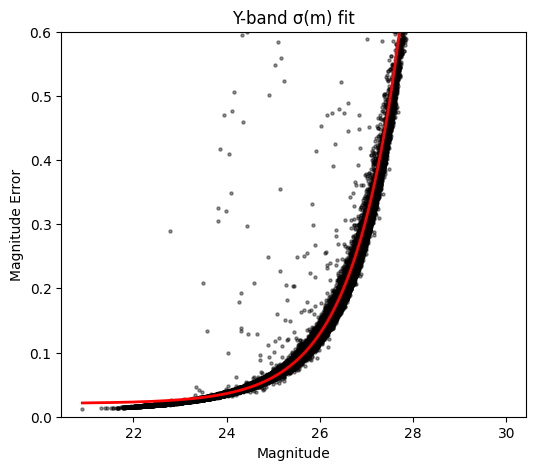

Y-band 5σ depth = 28.33

i-band fit parameters:
a, b, c = [6.54690521e-12 9.27829088e-01 4.22699473e-03]


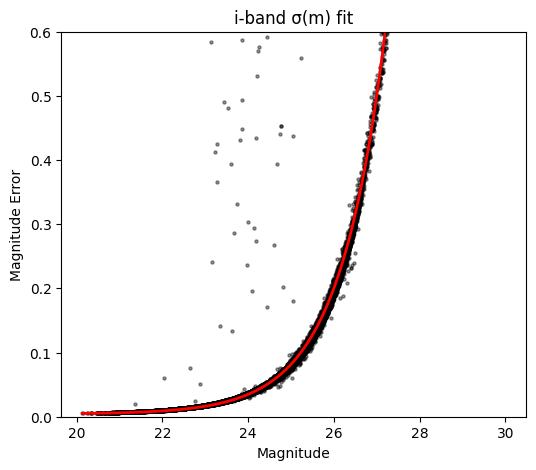

i-band 5σ depth = 27.84

z-band fit parameters:
a, b, c = [5.14416243e-12 9.21583025e-01 4.02531501e-03]


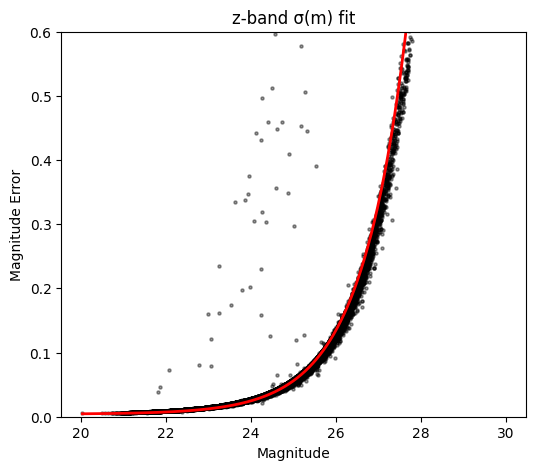

z-band 5σ depth = 28.29

Final 5σ depths:
Y: 28.33033574281515
i: 27.839595107450684
z: 28.29012880857992


In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit, brentq
from astropy.coordinates import SkyCoord
import astropy.units as u

# ============================================================
# File paths
# ============================================================
i_file  = "/Users/aishwarya/Desktop/Lyman_alpha_2/CAT/i_band_depth.cat"
z_file  = "/Users/aishwarya/Desktop/Lyman_alpha_2/CAT/z_band_depth.cat"
y_file  = "/Users/aishwarya/Desktop/Lyman_alpha_2/CAT/LBG_Y_Y_final.cat"

# ============================================================
# Load catalogs
# ============================================================
colnames = ["ID", "X", "Y", "RA", "DEC",
            "MAG_APER", "MAGERR_APER",
            "MAG_AUTO", "MAGERR_AUTO", "FLAGS"]

i_df = pd.read_csv(i_file, sep=r"\s+", comment="#", names=colnames)
z_df = pd.read_csv(z_file, sep=r"\s+", comment="#", names=colnames)
y_df = pd.read_csv(y_file, sep=r"\s+", comment="#", names=colnames)

# ============================================================
# Zero points
# ============================================================
ZP_i, ZP_z, ZP_y = 31.354, 31.524, 30.3382
zp_err_i, zp_err_z, zp_err_y = 0.004, 0.004, 0.009

for df, zp, zp_err in zip(
        [i_df, z_df, y_df],
        [ZP_i, ZP_z, ZP_y],
        [zp_err_i, zp_err_z, zp_err_y]):

    df["MAG_APER_CAL"] = df["MAG_APER"] + zp
    df["MAGERR_APER_CAL"] = np.sqrt(df["MAGERR_APER"]**2 + zp_err**2)

# ============================================================
# Cross-match to align catalogs
# ============================================================
y_coords = SkyCoord(y_df.RA.values*u.deg, y_df.DEC.values*u.deg)
z_coords = SkyCoord(z_df.RA.values*u.deg, z_df.DEC.values*u.deg)
i_coords = SkyCoord(i_df.RA.values*u.deg, i_df.DEC.values*u.deg)

idx_z, sep_z, _ = y_coords.match_to_catalog_sky(z_coords)
idx_i, sep_i, _ = y_coords.match_to_catalog_sky(i_coords)

match_radius = 1.0  # arcsec
z_match = sep_z.arcsec < match_radius
i_match = sep_i.arcsec < match_radius

def align_mag_err(n, df, idx, mask):
    mag = np.full(n, np.nan)
    err = np.full(n, np.nan)
    mag[mask] = df.MAG_APER_CAL.values[idx[mask]]
    err[mask] = df.MAGERR_APER_CAL.values[idx[mask]]
    return mag, err

y_mag = y_df.MAG_APER_CAL.values
y_err = y_df.MAGERR_APER_CAL.values

z_mag, z_err = align_mag_err(len(y_mag), z_df, idx_z, z_match)
i_mag, i_err = align_mag_err(len(y_mag), i_df, idx_i, i_match)

# ============================================================
# Common mask
# ============================================================
mask = (~np.isnan(y_mag)) & (~np.isnan(z_mag)) & (~np.isnan(i_mag))

y_mag, y_err = y_mag[mask], y_err[mask]
z_mag, z_err = z_mag[mask], z_err[mask]
i_mag, i_err = i_mag[mask], i_err[mask]

# ============================================================
# Stable exponential sigma model
# sigma(m) = a * exp(b*m) + c
# ============================================================

def sigma_model(m, a, b, c):
    # Clip exponent to avoid overflow
    exponent = np.clip(b * m, -100, 100)
    return a * np.exp(exponent) + c

def fit_sigma_exponential(mag, err, bandname):

    # Clean data
    valid = np.isfinite(mag) & np.isfinite(err)
    mag = mag[valid]
    err = err[valid]

    # Restrict to faint regime (background dominated)
    mask_range = (mag > 20) & (mag < 30)
    mag = mag[mask_range]
    err = err[mask_range]

    # Initial guess (physically motivated)
    p0 = [1e-7, 0.45, 0.001]

    # Bounds to prevent nonsense solutions
    bounds = (
        [1e-12, 0.0, 0.0],   # lower bounds
        [1e-2,   2.0,  0.1]  # upper bounds
    )

    popt, pcov = curve_fit(
        sigma_model,
        mag,
        err,
        p0=p0,
        bounds=bounds,
        maxfev=20000
    )

    a_fit, b_fit, c_fit = popt
    print(f"\n{bandname} fit parameters:")
    print("a, b, c =", popt)

    # ========================================================
    # Plot
    # ========================================================
    x_fine = np.linspace(mag.min(), mag.max(), 1000)
    y_fit = sigma_model(x_fine, *popt)

    plt.figure(figsize=(6,5))
    plt.scatter(mag, err, s=5, alpha=0.4, color='black')
    plt.plot(x_fine, y_fit, color='red', lw=2)
    plt.xlabel("Magnitude")
    plt.ylabel("Magnitude Error")
    plt.title(f"{bandname} σ(m) fit")
    #plt.xlim(25,28)
    plt.ylim(0,0.6)
    plt.show()

    # ========================================================
    # Compute 5σ depth
    # ========================================================
    sigma_5 = 2.5 / (np.log(10) * 1)

    def root_func(m):
        return sigma_model(m, *popt) - sigma_5

    m_5sigma = brentq(root_func, 20, 30)

    print(f"{bandname} 5σ depth = {m_5sigma:.2f}")

    return popt, m_5sigma

# ============================================================
# Run fits
# ============================================================

popt_y, lim_y = fit_sigma_exponential(y_mag, y_err, "Y-band")
popt_i, lim_i = fit_sigma_exponential(i_mag, i_err, "i-band")
popt_z, lim_z = fit_sigma_exponential(z_mag, z_err, "z-band")

print("\nFinal 5σ depths:")
print("Y:", lim_y)
print("i:", lim_i)
print("z:", lim_z)